### 250409 KC解释生成

大概流程：
    （1）对df_KC_tree中的KC按照level分堆，用bert_base_uncased生成嵌入后，在同level内生成topK相似KC的字典（参考gen_prompt中的相关code）
    （2）以KC为中心重构df_Qmat;并按照交互记录df中的频率降序，保留topK个高频pid（且确保相似KC不包含同样的pid）；
    （3）将kc_short中的题目文本内容作为新的列合并至df_Qmat；
    （4）根据规则生成

##### 读取数据

In [ ]:
import pandas as pd
import json
import ast
import os
import re
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)  # 忽略FutureWarning类型的警告
import random
random.seed(42)  # 全局随机种子设置

"""读取数据，统计数量"""
df = pd.read_csv('/mnt/new_pfs/liming_team/auroraX/cdm_data/NIPS/data/train_data/train_task_3_4.csv',
                 usecols=['QuestionId', 'UserId', 'IsCorrect'])
df_Qmat = pd.read_csv('/mnt/new_pfs/liming_team/auroraX/cdm_data/NIPS/data/metadata/question_metadata_task_3_4.csv')
df = df.merge(df_Qmat[['QuestionId', 'SubjectId']], on='QuestionId', how='left')
df_KC_tree = pd.read_csv('/mnt/new_pfs/liming_team/auroraX/cdm_data/NIPS/data/metadata/subject_metadata.csv')
with open(f'data/nips34_short.json', 'r', encoding='utf-8') as file:
    exer_content = json.load(file)

exer_content = {int(k):v for k,v in exer_content.items()}



# 先剔除掉df_KC_tree中没有交互数据的kc
result = set()
for ind, row in df_Qmat.iterrows():        # 3-655，题库涉及的KC（实际操作时将根部的两层KC剔除）
    temp = ast.literal_eval(row['SubjectId'])
    result.update(temp)
print(len(df_KC_tree))
df_KC_tree = df_KC_tree[df_KC_tree['SubjectId'].isin(result)]
print(len(df_KC_tree))


# 根据kc的ID查询level
dict_kid2level = dict(zip(df_KC_tree.loc[:, "SubjectId"], df_KC_tree.loc[:, "Level"]))


# 不同level的KC组成的子df
df_KCbyLevels = {}
for level in [0,1,2,3]:
    # 提取出特定KC的子df
    df_KCbyLevels[level] = df_KC_tree[df_KC_tree['Level'] == level]


# 假设查询id为ind的KC的同级别KC的ID列表
# df_KCbyLevels[dict_kid2level[ind]]["SubjectId"].tolist()


# 获取问题ID计数
n_exer = df['QuestionId'].value_counts(ascending=False)   # 948，降序排列
pids = [pid for pid, _ in n_exer.items()]                 # 0-947，共948题（致密）
pids.sort()
high_freq_pids = n_exer.index.tolist()

##### 嵌入

In [ ]:
import json
import torch
import numpy as np
from transformers import BertTokenizer, BertModel


# NIPS34的KC:将dataframe的两列转为字典，第一列作为键，第二列作为值
questions = dict(zip(df_KC_tree.loc[:, "SubjectId"], df_KC_tree.loc[:, "Name"]))

# 输出文件名
file_emb = r'/mnt/new_pfs/liming_team/auroraX/songchentao/MyCDM/data/nips34_kc_name_embeds.npy'
file_token = r'/mnt/new_pfs/liming_team/auroraX/songchentao/MyCDM/data/nips34_kc_name_tokens.json'
file_simKCs = r'/mnt/new_pfs/liming_team/auroraX/songchentao/MyCDM/data/nips34_kc_sim_top3.json'

# 整理为list
inds = []
contents = []
for ind, kc_name in questions.items():
    contents.append(kc_name)
    inds.append(ind)

# 批量处理文本
tokenizer = BertTokenizer.from_pretrained('/mnt/new_pfs/liming_team/auroraX/songchentao/llama/bert-base-uncased')
model = BertModel.from_pretrained('/mnt/new_pfs/liming_team/auroraX/songchentao/llama/bert-base-uncased')
model.eval()
with torch.no_grad():
    # 分词
    exer_tokenized = tokenizer(contents, padding=True, truncation=True, max_length=256, return_tensors='pt')
    # 嵌入
    bert_output = model(**exer_tokenized)
    exer_emb = bert_output.last_hidden_state[:, 0]  # , :
    exer_emb = torch.nn.functional.normalize(exer_emb, p=2, dim=1)  # 归一化 
    print(exer_emb.shape)

# # 保存嵌入结果
# np.save(file_emb, exer_emb.detach().numpy())

In [ ]:
print(torch.sqrt(torch.sum(exer_emb**2, dim=1)))
exer_emb = exer_emb.detach().numpy()

##### 获取相似的top3同级kc

In [ ]:
# 先按照顺序排好嵌入数组
kc_emb = np.zeros((max(inds)+1, exer_emb.shape[1]))
for idx, ind in enumerate(inds):
    kc_emb[ind, :] = exer_emb[idx, :]


# 计算并保存topk相似kc节点
def calculate_similarity(_embeddings):
    """
    计算学生描述之间的相似度
    """
    _similarity_matrix = np.zeros((len(_embeddings), len(_embeddings)))
    for i in range(len(_embeddings)):
        for j in range(len(_embeddings)):
            # 计算余弦相似度
            similarity = np.dot(_embeddings[i], _embeddings[j])
            _similarity_matrix[i][j] = similarity
    return _similarity_matrix


"""计算并显示相似度矩阵"""
similarity_matrix = calculate_similarity(kc_emb)
# print("\n题目描述相似度矩阵:")
# print(similarity_matrix)

# 转存相似度信息
dict_sim = {}
for ind_row in inds:
    temp = similarity_matrix[ind_row, :].squeeze()
    # 排序并取负号实现倒序
    temp = np.argsort(temp)[::-1].tolist()
    # # 剔除自身
    temp = temp[1:]
    # 剔除不存在的学生id
    temp = [elem for elem in temp if elem in df_KCbyLevels[dict_kid2level[ind_row]]["SubjectId"].tolist()]  # 这里应该是同级KC的list(只在同级KC中搜寻topK相似)
    # 保留top20并记录
    dict_sim[ind_row] = temp[:3]

with open(file_simKCs, 'w', encoding='utf-8') as json_file:
    json.dump(dict_sim, json_file, indent=4, ensure_ascii=False)


In [ ]:
print(len(df_KC_tree))
print(df_KC_tree.head())
# print(type(df_KC_tree.loc[1, 'top3_sim']))

In [ ]:
# 将相似关系、高频题目等生成prompt所需的所有信息都集成到df_KC_tree中
df_KC_tree['top3_sim'] = df_KC_tree['SubjectId'].map(dict_sim)

# 从最高频的题目开始遍历
dict_top5_pids = {k:[] for k,v in dict_sim.items()}
for pid in high_freq_pids:
    # 从df_Qmat获取题目的涉及的kc list
    kcs = ast.literal_eval(df_Qmat.loc[df_Qmat['QuestionId']==pid, "SubjectId"].iloc[0])
    for kc in kcs:
        sim_kcs = df_KC_tree.loc[df_KC_tree['SubjectId']==kc, "top3_sim"].iloc[0]
        if len(dict_top5_pids[kc]) >= 5:
            # 判断dict_top5_pids中对应kc的列表是否已满，是则跳过
            continue
        elif bool(set(sim_kcs) & set(kcs)):
            # 否则判断题目的kcs是否包含当前kc的相似kc，是则跳过
            continue
        else:
            # 否则将题目添加到dict_top5_pids中对应kc的列表中
            dict_top5_pids[kc].append(pid)

# 将高频题目信息都集成到df_KC_tree中
df_KC_tree['top5_exer'] = df_KC_tree['SubjectId'].map(dict_top5_pids)
print(df_KC_tree.head())


##### 生成prompt（目标格式为[{"system": <system_prompt>, "prompt": <user_prompt>}, ...]）
##### 250415 新增英文版prompt

In [ ]:
eng = True  # 使用英文prompt

system_prompt_eng = """If you are a seasoned math teacher, you need to generate explanations for each knowledge point in a knowledge graph.
I will provide you with the name of the knowledge point and corresponding example problems, as well as names and example problems of distractor knowledge points that are not equivalent to it. Please carefully compare them and generate a core explanation for each knowledge point. If you do well, I will give you a $10 tip for this round. When making decisions, think as thoroughly as possible; write the thinking part after "Thinking," enclosing the thinking part with the symbols 【】.
Therefore, the description generated for the knowledge point is:
【Thinking: XXX】The core explanation of the knowledge point is: XXX
"""

system_prompt = """假如你是一位资深的数学老师，你需要给知识图谱的每一个知识点生成知识点的解释。
我将给你这个知识点的名称和对应的例题，还有与它不等价的干扰知识点的名称和对应的例题。请仔细比较，生成每一个知识点的核心解释。如果你做的好，这一轮我将给你10美元小费，做决定的时候要尽可能充分思考，思考的部分写在思考后面，思考部分前后用符号【】包裹起来。
所以为该知识点生成的描述是：【思考：XXX】该知识点的核心解释为：XXX
"""

user_prompt = """
知识点名称：{} 
-----
该知识点的例题：###例题1###
题目：{}
###例题2###
题目：{}
###例题3###
题目：{}
###例题4###
题目：{}
###例题5###
题目：{}
-----
干扰知识点：[干扰知识点1]{}
[干扰知识点1的例题]###例题1###
题目：{}
###例题2###
题目：{}
###例题3###
题目：{}
###例题4###
题目：{}
###例题5###
题目：{}
[干扰知识点2]{}
[干扰知识点2的例题]###例题1###
题目：{}
###例题2###
题目：{}
###例题3###
题目：{}
###例题4###
题目：{}
###例题5###
题目：{}
[干扰知识点3]{}
[干扰知识点3的例题]###例题1###
题目：{}
###例题2###
题目：{}
###例题3###
题目：{}
###例题4###
题目：{}
###例题5###
题目：{}
"""

user_prompt_eng = """
Knowledge Point Name: {} 
-----
Example Problems for This Knowledge Point:
### Problem 1 ###
Question: {}
### Problem 2 ###
Question: {}
### Problem 3 ###
Question: {}
### Problem 4 ###
Question: {}
### Problem 5 ###
Question: {}
-----
Distractor Knowledge Points:
[Distractor Knowledge Point 1] {}
[Distractor Knowledge Point 1's Example Problems]
### Problem 1 ###
Question: {}
### Problem 2 ###
Question: {}
### Problem 3 ###
Question: {}
### Problem 4 ###
Question: {}
### Problem 5 ###
Question: {}
[Distractor Knowledge Point 2] {}
[Distractor Knowledge Point 2's Example Problems]
### Problem 1 ###
Question: {}
### Problem 2 ###
Question: {}
### Problem 3 ###
Question: {}
### Problem 4 ###
Question: {}
### Problem 5 ###
Question: {}
[Distractor Knowledge Point 3] {}
[Distractor Knowledge Point 3's Example Problems]
### Problem 1 ###
Question: {}
### Problem 2 ###
Question: {}
### Problem 3 ###
Question: {}
### Problem 4 ###
Question: {}
### Problem 5 ###
Question: {}

"""

list_prompts = []
# 遍历df_KC_tree中的每个KC
for ind, row in df_KC_tree.iterrows():
    temp_contents = []
    idx = row["SubjectId"]
    kc = row["Name"]
    exers = row["top5_exer"]
    sim_kcs = row["top3_sim"]
    # 将当前题目自己的信息汇总保存
    temp_contents.append(kc)
    temp = [exer_content[elem] for elem in exers]
    while len(temp) < 5:
        if eng:
            temp.append("None")
        else:
            temp.append("无")  # 确保五个代表性题目的位置都占上，防止错位
    temp_contents.extend(temp)

    # 遍历相似知识点，整理信息后保存
    for sim_kc in sim_kcs:
        temp_contents.append(df_KC_tree.loc[df_KC_tree["SubjectId"]==sim_kc, "Name"].iloc[0])
        sim_exers = df_KC_tree.loc[df_KC_tree["SubjectId"]==sim_kc, "top5_exer"].iloc[0]
        _temp = [exer_content[elem] for elem in sim_exers]
        while len(_temp) < 5:
            if eng:
                _temp.append("None")
            else:
                _temp.append("无")
        temp_contents.extend(_temp)
    
    # 填补相似KC少于3个的特殊情况
    while len(temp_contents) < 24:
        if eng:
            temp_contents.append("None")
        else:
            temp_contents.append("无")

    # 使用temp_contents填充prompt模板，并汇总记录
    if eng:
        converted_item = {
        "idx": idx,
        "system": system_prompt_eng,
        "prompt": user_prompt_eng.format(*temp_contents)
        }
    else:
        converted_item = {
            "idx": idx,
            "system": system_prompt,
            "prompt": user_prompt.format(*temp_contents)
        }
    list_prompts.append(converted_item)

print(len(list_prompts))
json_string = json.dumps(list_prompts, ensure_ascii=False, indent=4)
print(json_string)

# 将JSON字符串保存到文件
if eng:
    with open(r'/mnt/new_pfs/liming_team/auroraX/songchentao/MyCDM/data/nips34_kc_discription_qwen_prompts_eng.json', 'w', encoding='utf-8') as f:
        f.write(json_string)
else:
    with open(r'/mnt/new_pfs/liming_team/auroraX/songchentao/MyCDM/data/nips34_kc_discription_qwen_prompts.json', 'w', encoding='utf-8') as f:
        f.write(json_string)


In [ ]:
print(df_KC_tree.head())
# 无需重复保存
df_KC_tree.to_csv('/mnt/new_pfs/liming_team/auroraX/cdm_data/NIPS/data/metadata/subject_metadata_gathered.csv', index=False)

##### 调用qwen API获得返回后，整理格式

In [ ]:
import json

def extract_core_explanation(text):
    marker = "该知识点的核心解释为："
    last_occurrence = text.rfind(marker)
    if last_occurrence != -1:
        return text[last_occurrence + len(marker):]
    return ""

with open(r'data/nips34_kc_discription_qwen_response.json', 'r', encoding='utf-8') as file:
    responses = json.load(file)

refined_contents = []

for temp in responses:
    temp["output"] = extract_core_explanation(temp["output"])
    refined_contents.append(temp)

with open(r'data/nips34_kc_discription_qwen_response_refined.json', 'w', encoding='utf-8') as json_file:
    json.dump(refined_contents, json_file, indent=4, ensure_ascii=False)


##### 250415 short_kc格式订正

In [ ]:
import json

def split_string(text):
    """
    现有字符串，按照如下要求切分：
        （1）第一个 "[knowledge points]\n" 之后，到下一个"\n"之前；
        （2）紧接着（1）直到末尾.
    """
    # 查找第一个 "[knowledge points]\n" 的位置
    start_marker = "[knowledge points]\n"
    start_pos = text.find(start_marker)
    if start_pos == -1:
        return None, None  # 没找到标记，返回空
    # 找到标记后的起始位置
    content_start = start_pos + len(start_marker)
    # 从起始位置查找下一个换行符
    next_newline = text.find("\n", content_start)
    if next_newline == -1:
        # 如果没找到下一个换行符，则第一部分是从标记后到结尾
        part1 = text[content_start:]
        part2 = ""
    else:
        # 第一部分：从标记后到下一个换行符
        part1 = text[content_start:next_newline]
        # 第二部分：从换行符后到结尾
        part2 = text[next_newline+1:]
    
    return part1, part2


# 读取KCID和解释的对应关系
with open(r'data/nips34_kc_discription_qwen_response_refined_eng.json', 'r', encoding='utf-8') as file:
    responses = json.load(file)
kc_id2text = {elem["idx"]:elem["output"] for elem in responses}

# 读取待处理文件
with open('data/nips34_short_kc.json', 'r', encoding='utf-8') as file:
    data_in = json.load(file)

# 读取Qmat
df_Qmat = pd.read_csv('/mnt/new_pfs/liming_team/auroraX/cdm_data/NIPS/data/metadata/question_metadata_task_3_4.csv')

# 读取KC名字和ID对应关系
df_KC_tree = pd.read_csv('/mnt/new_pfs/liming_team/auroraX/cdm_data/NIPS/data/metadata/subject_metadata.csv')
kc_name2id = df_KC_tree.set_index('Name')['SubjectId'].to_dict()

data_out = {}
# 遍历data_in中的每一个题目：切分字符串，对应查询kc_name2id后，再用ID查询解释，替换后更新值
for pid, content in data_in.items():
    # 切分KC路径和题目内容
    part1, part2 = split_string(content)
    # 切分具体KC名称
    kc_name_list = part1.split('->')
    kc_text_list = []
    for kc_name in kc_name_list:
        # 查询对应ID
        kc_id = kc_name2id[kc_name]
        # 匹配KC解释并记录
        kc_text_list.append(kc_id2text[kc_id])
    
    # 拼合结果并记录
    refined_value = "[Knowledge points]\n" + "->".join(kc_text_list) + part2
    data_out[pid] = refined_value

with open(r'data/nips34_short_kc_descrip.json', 'w', encoding='utf-8') as json_file:
    json.dump(data_out, json_file, indent=4, ensure_ascii=False)



### 250415 学情数据统计

In [4]:
import pandas as pd
import glob
import os


def combine_csv_files(directory_path):
    # 使用glob.glob获取目录下所有csv文件
    csv_files = glob.glob(os.path.join(directory_path, '*.csv'))
    
    # 创建空列表存储每个DataFrame
    dfs = []
    
    # 遍历读取每个文件
    for file in csv_files:
        df = pd.read_csv(file)
        dfs.append(df)
    
    # 合并所有DataFrame
    if dfs:
        combined_df = pd.concat(dfs, ignore_index=True)
        return combined_df
    else:
        return pd.DataFrame()

# 使用示例
combined_data = combine_csv_files('data/results')
print(len(combined_data))


60744060


In [5]:
# id2knowname是知识点ID到名字的映射
know_map_path = "/mnt/new_pfs/liming_team/auroraX/mnt2/CDM/online/DoA/JZX_all_kp_map.csv"

import pandas as pd
from tqdm import tqdm
import pandas as pd
import numpy as np
import json
from tqdm import tqdm
from collections import defaultdict

know_map = pd.read_csv(know_map_path)

id2xueke = {}
id2version = {}
id2grade = {}
id2knowname = {}
qid2diff = {}
for index,row in know_map.iterrows():  # tqdm(know_map.iterrows())
    this_id = row["knowledge_id"]
    qid2diff[this_id] = {}
    this_grade = row["knowledge_grade"]
    this_xueke = row["knowledge_subject"]
    this_version = row["knowledge_version"]
    id2xueke[this_id] = this_xueke
    id2version[this_id] = this_version
    id2grade[this_id] = this_grade
    id2knowname[this_id] = row["knowledge_name"]
    if pd.isna(row["knowledge_question_group"]):
        continue
    q_group = json.loads(row["knowledge_question_group"])
    for sub_group in q_group:
        this_diff = sub_group["difficulty"]
        this_qs = sub_group["question_group"]
        for sub_q in this_qs:
            qid2diff[this_id][sub_q["question_id"]] = this_diff


/tmp/ipykernel_539344/1894645371.py:12: DtypeWarning: Columns (7,30) have mixed types. Specify dtype option on import or set low_memory=False.
  know_map = pd.read_csv(know_map_path)


In [10]:
print(len(id2knowname))

import random

# 假设我们有一个字典
sample_dict = id2knowname

# 检查字典中是否有至少5个元素
if len(sample_dict) < 5:
    print("字典中没有足够的键值对来选择10个。")
else:
    # 随机选择10个键
    random_keys = random.sample(list(sample_dict.keys()), 10)

    # 创建一个新的字典来存储随机选择的键值对
    random_dict = {key: sample_dict[key] for key in random_keys}

    # 打印随机选择的键值对
    for key, value in random_dict.items():
        print(f"{key}: {value}")
        print(f"{type(key)}: {value}")


270852
35015225: 病毒的繁殖
<class 'int'>: 病毒的繁殖
35013381: 方程的意义
<class 'int'>: 方程的意义
35059574: 探究平面镜成像的特点之像与物的关系
<class 'int'>: 探究平面镜成像的特点之像与物的关系
35250961: 整百数的加减
<class 'int'>: 整百数的加减
35262630: 已知k求图形面积
<class 'int'>: 已知k求图形面积
81482: 递进式、连贯式
<class 'int'>: 递进式、连贯式
35010774: 已知不等式的解集求参数的值
<class 'int'>: 已知不等式的解集求参数的值
35232942: 测量平均速度实验中的测量读数
<class 'int'>: 测量平均速度实验中的测量读数
35426436: become
<class 'int'>: become
35252350: 绘制复式折线统计图
<class 'int'>: 绘制复式折线统计图


##### qc：学生选取交互次数大于50的

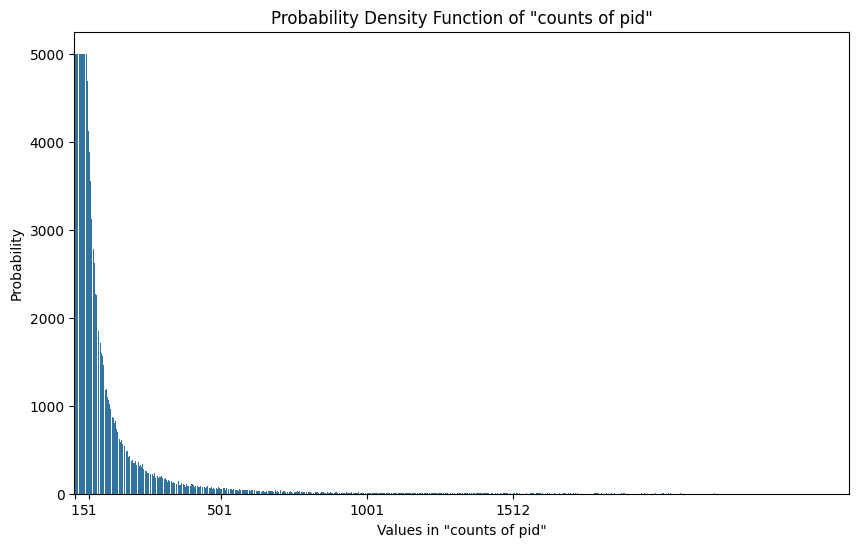

In [7]:
value_counts_user = combined_data['tal_id'].value_counts()

# 对pid和tal_id进行QC，统计pid的计数分布
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun', 'Arial Unicode MS', 'DejaVu Sans']
# 解决负号显示问题
plt.rcParams['axes.unicode_minus'] = False

# 子图2: PDF图
pdf = value_counts_user.value_counts()  # 此时index是单个学生的计数，value是有多少个学生的计数是index个
pdf_ = pdf.clip(upper=5000)
# pdf_ = pdf_[pdf_>=5]
# pdf_ = pdf_[pdf_.index>=5]
plt.figure(figsize=(10, 6))
sns.barplot(x=pdf_.index, y=pdf_.values)
plt.title('Probability Density Function of "counts of pid"')
plt.xlabel('Values in "counts of pid"')
plt.ylabel('Probability')
plt.xticks([0, 50, 500, 1000, 1500])  # , rotation=90
# plt.tight_layout()
plt.show()

##### qc:问题最好选总交互数量大于50的

In [ ]:
value_counts_exer = combined_data['question_id'].value_counts()

# 对pid和tal_id进行QC，统计pid的计数分布
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun', 'Arial Unicode MS', 'DejaVu Sans']
# 解决负号显示问题
plt.rcParams['axes.unicode_minus'] = False

# 子图2: PDF图
pdf = value_counts_exer.value_counts()  # 此时index是单个题目的计数，value是有多少道题的计数是index个
pdf_ = pdf.clip(upper=2000)
pdf_ = pdf_[pdf_>=5]
pdf_ = pdf_[pdf_.index>=5]
plt.figure(figsize=(10, 6))
sns.barplot(x=pdf_.index, y=pdf_.values)
plt.title('Probability Density Function of "counts of pid"')
plt.xlabel('Values in "counts of pid"')
plt.ylabel('Probability')
plt.xticks([0, 50, 500, 1000, 1500])  # , rotation=90
# plt.tight_layout()
plt.show()


In [ ]:
print(pdf_.index.max())

##### 尝试转存（无必要）

In [ ]:
import pandas as pd
import os


def process_dataframe(df, output_path):
    # 确保输出路径存在
    os.makedirs(output_path, exist_ok=True)
    
    # 遍历A列的unique值
    for value_a in df['tal_id'].unique():
        # 选择所有A列值为value_a的行
        sub_df = df[df['tal_id'] == value_a]
        
        # 按B列的时间戳排序（由早到晚）
        sub_df_sorted = sub_df.sort_values(by='created_at')
        
        # 生成文件名并保存
        filename = f"{value_a}.csv"
        filepath = os.path.join(output_path, filename)
        sub_df_sorted.to_csv(filepath, index=False)
        print(f"已保存文件: {filepath}")

# 使用示例
process_dataframe(combined_data, "data/result_user")  # 处理并保存到指定路径


##### kc—wise统计

In [16]:
import random
random.seed(42)

value_counts_kc = combined_data['knowledge_id'].value_counts()
print(len(value_counts_kc))  # ~5w
temp = value_counts_kc[value_counts_kc>=10000]
print(len(temp))  # 1202

# 在temp中随机抽取10个kc，获取子df
temp = temp.index.tolist()
temp = random.sample(temp, 20)

# 声明输出
dict_out = {kid: [] for kid in temp}

# 对子df中的question_id进行计数，对计数量达标的题目进行正确率统计并保存
for kid in temp:
    df_ = combined_data[combined_data['knowledge_id']==kid]
    print(len(df_))

    # 筛选符合统计条件的pid
    pid_count = df_['question_id'].value_counts()
    pid_count = pid_count[pid_count>=50].index.tolist()

    # 对于符合统计条件的pid，计算正确率
    for pid in pid_count:
        _temp = df_.loc[df_['question_id']==pid, 'status']
        _temp = _temp == 1
        dict_out[kid].append(sum(_temp)/len(_temp))


49891
1202
31425
111869
17195
18527
19765
26596
32888
10605
35985
13070
89918
92815
34421
20040
19121
11353
103532
10338
21415
13118


In [ ]:
"""
配色方案（根据数据长度动态分配）
"""

# # 19. 单一颜色渐变（蓝色示例）
# def single_hue_gradient(color, n):
#     rgba = to_rgba(color)
#     h, l, s = colorsys.rgb_to_hls(*rgba[:3])
#     return [colorsys.hls_to_rgb(h, 0.3 + (0.5 * i / (n-1)), s) for i in range(n)]

# blue_gradient = single_hue_gradient('blue', len(data))

# # 20. 双色渐变（从红色到蓝色）
# cmap = LinearSegmentedColormap.from_list("RedBlue", ["red", "blue"])
# red_blue_gradient = [cmap(i/(len(data)-1)) for i in range(len(data))]

# # 21. Viridis配色方案
# viridis = plt.cm.viridis(np.linspace(0, 1, len(data)))

# # 22. Plasma配色方案
# plasma = plt.cm.plasma(np.linspace(0, 1, len(data)))

# # 23. Inferno配色方案
# inferno = plt.cm.inferno(np.linspace(0, 1, len(data)))

# # 24. Magma配色方案
# magma = plt.cm.magma(np.linspace(0, 1, len(data)))

# # 25. Cividis配色方案
# cividis = plt.cm.cividis(np.linspace(0, 1, len(data)))

字体done


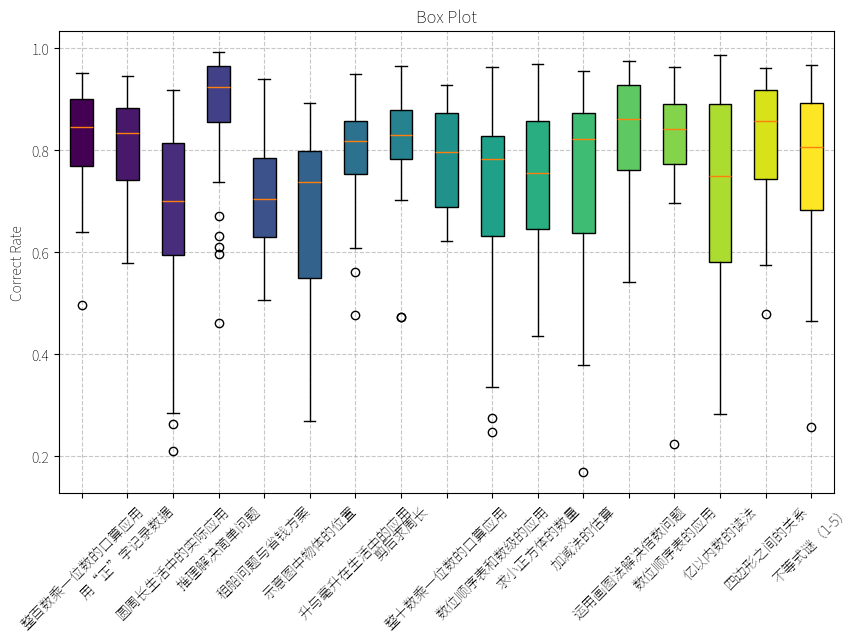

In [19]:
# 绘制盒须图
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.font_manager as fm
from matplotlib import rcParams
font_path = '/mnt/new_pfs/liming_team/auroraX/mnt2/CDM/Work1_ColdStart/NotoSansSC-VariableFont_wght.ttf'
fm.fontManager.addfont(font_path)
custom_font = fm.FontProperties(fname=font_path, weight='bold')
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = [custom_font.get_name(), 'DejaVu Sans', 'Bitstream Vera Sans', 'Arial', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

print("字体done")

# 提取数据和标签
# data = list(dict_out.values())
# labels = list(dict_out.keys())
# labels = [id2knowname[int(elem.strip("jzx1.5_zsd_"))] for elem in labels]


data = []
labels = []
while len(data)<=15:
    for idx, da in dict_out.items():
        if int(idx.strip("jzx1.5_zsd_")) in id2knowname.keys():
            data.append(da)
            labels.append(id2knowname[int(idx.strip("jzx1.5_zsd_"))])


# 创建图形和坐标轴
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制盒须图
bp = ax.boxplot(data, patch_artist=True)

# 设置x轴刻度标签
ax.set_xticklabels(labels, rotation=45)

# 为每个盒子设置颜色
# 21. Viridis配色方案
viridis = plt.cm.viridis(np.linspace(0, 1, len(data)))
for patch, color in zip(bp['boxes'], viridis[:len(data)]):
    patch.set_facecolor(color)

# 美化图表
ax.set_title('Box Plot')
ax.set_ylabel('Correct Rate')
ax.grid(True, linestyle='--', alpha=0.7)

# 设置轮廓颜色为深灰色
# for element in ['boxes', 'whiskers', 'fliers', 'means', 'medians', 'caps']:
#     if element in bp:
#         for item in bp[element]:
#             item.set(color='#444444', linewidth=1.5) 

# plt.tight_layout()
plt.show()